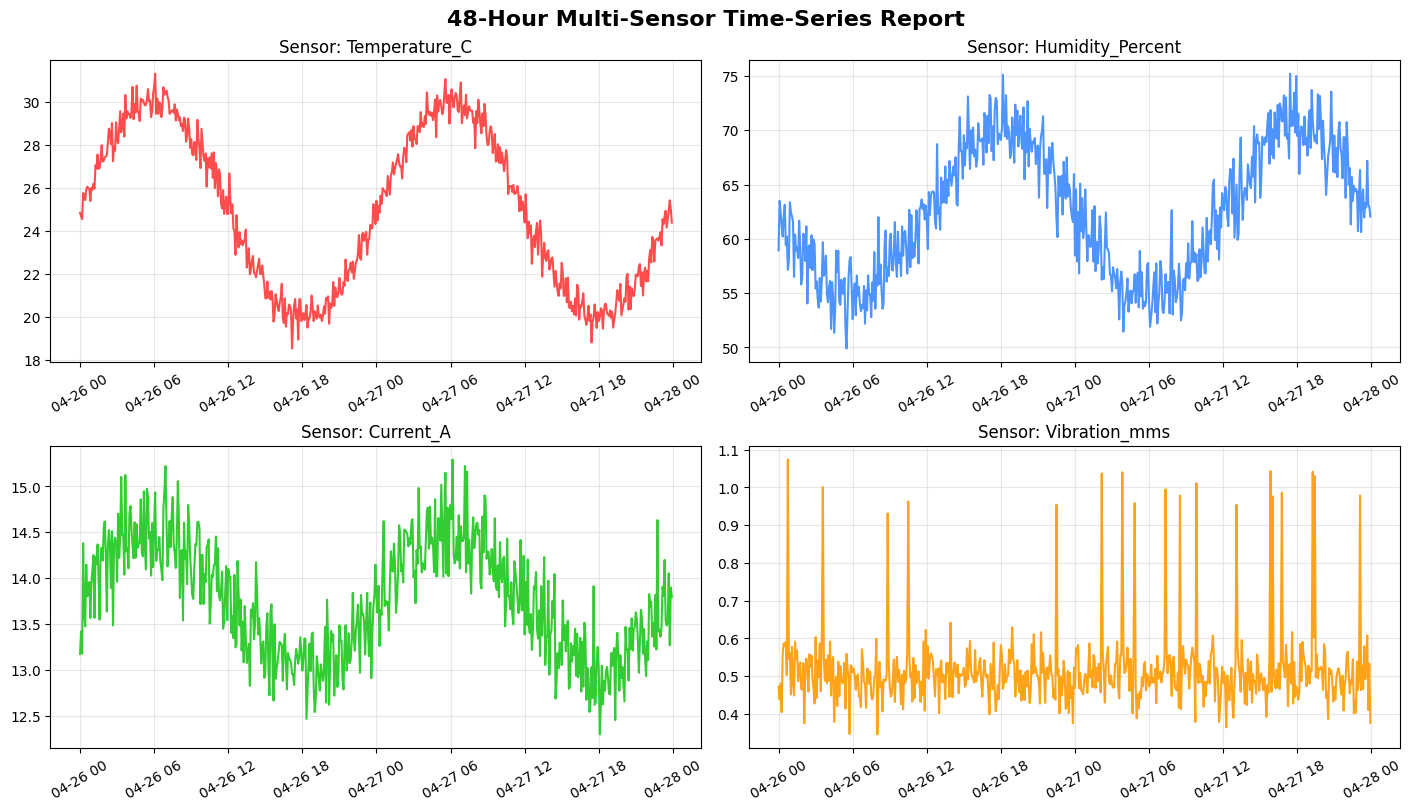

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# SIMULATE DATA (48 hours @ 5-min intervals = 576 readings)
time_idx = pd.date_range(start="2026-04-26", periods=48*12, freq="5min")
n = len(time_idx)

# Create syntatic Correlations
# Temperature follows a slight sine wave (day/night cycle)
temp = 25 + 5 * np.sin(np.linspace(0, 4*np.pi, n)) + np.random.normal(0, 0.5, n)
# Humidity is inversely correlated with temperature
humidity = 100 - (temp * 1.5) + np.random.normal(0, 2, n)
# Current rises slightly as temperature (cooling load) increases
current = 10 + (temp * 0.15) + np.random.normal(0, 0.3, n)
# Vibration is mostly independent but has random spikes
vibration = np.random.normal(0.5, 0.05, n) + np.where(np.random.rand(n) > 0.98, 0.5, 0)

df = pd.DataFrame({
    "Temperature_C": temp,
    "Humidity_Percent": humidity,
    "Current_A": current,
    "Vibration_mms": vibration
}, index=time_idx)

# CREATE 4-PANEL TIME-SERIES FIGURE (Skill: Subplots & Layout)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True) #constrained_layout=True: prevents the title of one chart from squishing into the labels of the one below it.
fig.suptitle("48-Hour Multi-Sensor Time-Series Report", fontsize=16, fontweight='bold')

cols = df.columns
colors = ['#ff4d4d', '#4d94ff', '#33cc33', '#ffa31a']



# The Loop (for i, col in enumerate): Instead of writing the code for a chart four times, the computer "loops" through the list of sensors and draws them one by one.
for i, col in enumerate(cols):
    ax = axes[i//2, i%2]
    ax.plot(df.index, df[col], color=colors[i], linewidth=1.5)
    ax.set_title(f"Sensor: {col}")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.savefig("timeseries_report.png")



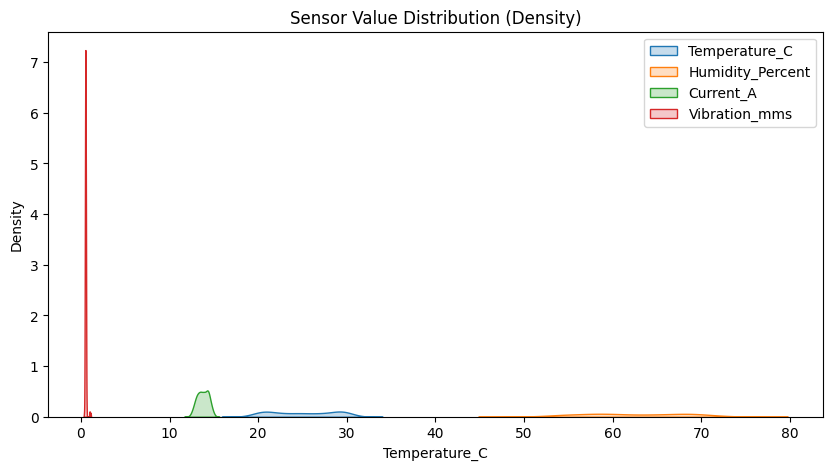

In [13]:

 #  CREATE DISTRIBUTION PANEL ( Seaborn)
plt.figure(figsize=(10, 5))
for i, col in enumerate(cols):
    sns.kdeplot(df[col], fill=True, label=col)
plt.title("Sensor Value Distribution (Density)")
plt.legend()
plt.savefig("distribution_report.png")

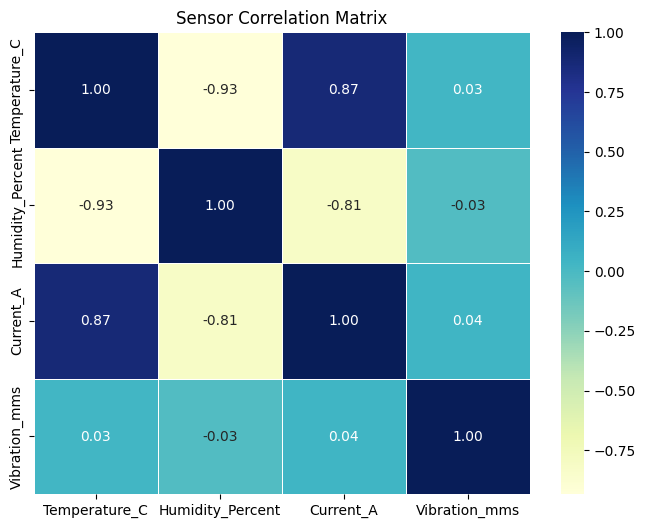

In [14]:
#  CREATE CORRELATION HEATMAP (Seaborn Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Sensor Correlation Matrix")
plt.savefig("correlation_report.png")

In [16]:
# # 5. GENERATE HTML REPORT
html_content = f"""
<html>
<head><title>Sensor Visualisation Report</title></head>
<body style="font-family: Arial; text-align: center; background-color: #f4f4f4;">
    <h1>Multi-Sensor Analysis Report</h1>
    <p>Generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}</p>
    <hr>
    <h3>1. Time-Series Analysis</h3>
    <img src="timeseries_report.png" width="800">
    <h3>2. Statistical Distributions</h3>
    <img src="distribution_report.png" width="800">
    <h3>3. Correlation Heatmap</h3>
    <img src="correlation_report.png" width="600">
</body>
</html>
"""

with open("Sensor_Report.html", "w") as f:
    f.write(html_content)

print("Project 3 Complete: All figures saved and 'Sensor_Report.html' generated.")

Project 3 Complete: All figures saved and 'Sensor_Report.html' generated.
